# Exercises XP: Guided Student Notebook

This guided notebook follows the **content on the platform**. Some cells are **prefilled** and must be **executed only**. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

**Learning points** appear when a concept is important for intuition or to help you learn new tricks/concepts related to other AI topics.


## Objectives

**What you will learn**  
- The fundamentals of deep learning and neural networks.
- How to build and train simple neural networks using TensorFlow or Keras.
- The concepts of forward and backward propagation.
- How to visualize and interpret model predictions.

**What you will create**  
- A simple perceptron-based decision system.
- A neural network for classifying handwritten digits from the MNIST dataset.
- A forward propagation calculation for predicting house prices.
- A Python implementation of forward and backward propagation.
- Visualizations of predictions made by a neural network on the MNIST dataset.


## 🌟 Exercise 1: Small Quiz

**As stated in the instructions**  
- What is the key difference between traditional machine learning and deep learning?  
- How do artificial neural networks mimic the human brain?  
- Why does deep learning perform better on large datasets compared to traditional machine learning?  
- What are some challenges of deep learning, and how can they be addressed?  
- What is feature engineering, and why is it not needed in deep learning?  
- What role do hidden layers play in a deep learning model?  
- In an artificial neural network, what is the function of an activation function?

**Guidance**  
Answer in full sentences. Use concise definitions first, then add one concrete example for any two questions to demonstrate understanding.

**To-Do:** Write your answers below.

*Solution*:

- Traditional ML usually requires human experts to manually identify and create the relevant features (feature engineering), while DL does that autonomously by analyzing raw data  

- (1) Similar to the 86 billion neurons in the human brain, ANNs consist of layers of interconnected nodes; (2) ANN systems learn from data by adjusting connection weights via backpropagation, a technique that minimizes errors, much like the brain strengthens connections through experience; (3) Each artificial neuron's connection has a weight (representing its significance) that determines how information is passed, mimicking the strength of synapses in biological neural networks.

- Deep learning outperforms traditional machine learning on large datasets because its multi-layered neural network architecture can automatically learn complex, non-linear features from raw data, whereas traditional models require manual feature engineering. Performance scales with data size, while traditional methods hit performance plateaus.

- Key Deep Learning Challenges and Solutions:

    - Data Scarcity and Quality: Deep learning requires large, high-quality, labeled datasets.
        - Solution: Use data augmentation (rotating, flipping data) to expand datasets, transfer learning (fine-tuning pre-trained models) to train with less data, or semi-supervised learning.

     - Overfitting: Models perform well on training data but poorly on new data.
        - Solution: Implement regularization techniques such as dropout, early stopping, and weight regularization (L1/L2).

    - High Computational Costs: Training large models requires significant GPU/TPU resources.
        - Solution: Use cloud-based platforms, distributed training.

    - "Black Box" Problem (Lack of Interpretability): It is difficult to understand how models reach decisions.
        - Solution: Apply techniques like Explainable AI (XAI).

-  Feature engineering is the process of selecting, transforming, and creating new input variables (features) from raw data to improve machine learning model accuracy. It is less necessary in deep learning because neural networks automatically perform "feature learning" identifying complex, non-linear patterns within raw data directly, eliminating manual feature design.

- Hidden layers in deep learning models are the intermediate layers between input and output, functioning as the engine for learning complex, non-linear patterns. They transform input data into hierarchical representations — identifying simple features initially and increasingly complex structures later — by applying weighted connections and activation functions.

- In ANN, the primary function of an activation function is to introduce non-linear properties to the network, allowing it to learn and model complex, non-linear relationships between input data and output predictions.

## 🌟 Exercise 2: Building a Simple Perceptron Decision System

**As stated in the instructions**  
You will create a perceptron-based decision system to decide whether you should go outside based on two inputs:
- Temperature in °F
- Rainy where Yes is 1 and No is 0

Given parameters: Temperature weight 0.6, Rain weight 0.4, Bias 2. Compute the weighted sum
\[ $\text{Weighted Sum} = 0.6\cdot \text{Temperature} + 0.4\cdot \text{Rain} + \text{Bias}$ \]
Apply a step activation:
- If Weighted Sum > 20, output 1
- If Weighted Sum $\le$ 20, output 0

Evaluate:  
Case 1: Temperature 70°F, Rain 0  
Case 2: Temperature 50°F, Rain 1

**Guidance**  
Implement the weighted sum function yourself. Use a reusable step activation. Then compute the two cases and print the decision for each.

**Learning point**  
A perceptron implements a linear decision boundary. The bias shifts the threshold. Use step activation for simple binary rules. Prefer differentiable activations when training with gradient descent.

![image.png](https://github.com/user-attachments/assets/3c4f3261-164d-4039-8e1c-aff2db7162dd)


In [2]:
# PREFILLED: just execute
from typing import Tuple

W_TEMP = 0.6
W_RAIN = 0.4
BIAS   = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    """Return 1 if s > threshold else 0."""
    return 1 if s > threshold else 0


In [3]:
# To-Do: implement weighted_sum then use it to compute the two cases
def weighted_sum(temperature_f: float, rain01: int) -> float:
    """Compute s = 0.6*Temperature + 0.4*Rain + Bias."""
    return W_TEMP * temperature_f + W_RAIN * rain01 + BIAS

# To-Do: compute decisions for the two cases and print them
case1 = (70, 0)  # Temperature=70, Rain=0
case2 = (50, 1)  # Temperature=50, Rain=1

s1 = weighted_sum(*case1)
s2 = weighted_sum(*case2)
y1 = step_activation(s1)
y2 = step_activation(s2)

print({"case1": {"sum": s1, "decision": y1}, "case2": {"sum": s2, "decision": y2}})


{'case1': {'sum': 44.0, 'decision': 1}, 'case2': {'sum': 32.4, 'decision': 1}}


**To-Do:** Interpret your results. Did the perceptron suggest going outside in both cases? Why or why not? Explain using the threshold rule and the effect of bias.

*Solution*: Yes, in both cases the decision was 1. That happened because in both cases the activation function crossed the threshold of 20.0. That was highly influenced by the bias. If its absolute value were greater and if it were negative, the results could have been different.


## 🌟 Exercise 3: Building a Simple Neural Network with TensorFlow or Keras

**As stated in the instructions**  
Build a classifier for MNIST with:
- One input layer
- One hidden layer with 128 neurons and ReLU activation
- One output layer with 10 neurons and softmax activation

Steps:
1. Import TensorFlow and needed modules from `tensorflow.keras`
2. Load the MNIST dataset
3. Normalize data by dividing by 255.0
4. One-hot encode the labels
5. Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
6. Compile with optimizer `adam`, loss `categorical_crossentropy`, metrics `accuracy`
7. Train and evaluate on the test set

**Guidance**  
You will execute prefilled boilerplate for imports and dataset loading. You will complete the one-hot encoding and the model specification, compile, train, and evaluate.

**Learning point**  
Normalization stabilizes optimization. One-hot encoding matches softmax outputs to target vectors. ReLU accelerates training by avoiding saturation, while softmax maps logits to a probability simplex.

![image.png](https://github.com/user-attachments/assets/61737b80-69cb-41a1-aea5-76092cd2a373)


In [4]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


TensorFlow: 2.21.0
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [5]:
# To-Do: one-hot encode labels y_train and y_test using to_categorical
# Hints: use to_categorical
y_train_oh = to_categorical(y_train)
y_test_oh  =to_categorical(y_test)

print("Labels one-hot:", y_train_oh.shape, y_test_oh.shape)


Labels one-hot: (60000, 10) (10000, 10)


In [6]:
# To-Do:  Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.summary()

/opt/miniconda3/envs/di-genai/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# To-Do: compile the model with adam, categorical_crossentropy, and accuracy
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [9]:
# To-Do: train then evaluate
history = model.fit(
    x_train,
    y_train_oh,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)
test_loss, test_acc = model.evaluate(x_test, y_test_oh)
print({"test_loss": float(test_loss), "test_acc": float(test_acc)})


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 680us/step - accuracy: 0.9224 - loss: 0.2712 - val_accuracy: 0.9683 - val_loss: 0.1175
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 636us/step - accuracy: 0.9646 - loss: 0.1185 - val_accuracy: 0.9690 - val_loss: 0.1015
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 632us/step - accuracy: 0.9761 - loss: 0.0813 - val_accuracy: 0.9777 - val_loss: 0.0785
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step - accuracy: 0.9817 - loss: 0.0616 - val_accuracy: 0.9762 - val_loss: 0.0794
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 643us/step - accuracy: 0.9855 - loss: 0.0469 - val_accuracy: 0.9770 - val_loss: 0.0815
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 291us/step - accuracy: 0.9753 - loss: 0.0786
{'test_loss': 0.07859096676111221, 'test_acc': 0.9753000140190125}


## 🌟 Exercise 4: Forward Propagation Calculation

**As stated in the instructions**  
Predict house prices given:
- Inputs: x₁ = 2000 square feet, x₂ = 3 bedrooms
- Weights: w₁ = 0.5, w₂ = 0.7
- Bias: b = 50,000
- Activation: ReLU

Compute z before activation, apply ReLU, and interpret the prediction.

**Guidance**  
Write scalar computations. Then reason about the role of the bias and ReLU on the output scale.

**Learning point**  
ReLU passes positive linear combinations unchanged and zeros out negatives. Bias sets the baseline prediction independent of inputs.
![](./figs/1.gif)

In [10]:
# To-Do: compute forward propagation for the given numbers
x1, x2 = 2000.0, 3.0
w1, w2 = 0.5, 0.7
b = 50000.0

# To-Do: compute z = x1*w1 + x2*w2 + b
z = x1*w1 + x2*w2 + b

# To-Do: apply ReLU
y = z if z >= 0 else 0

print({"z": z, "prediction": y})


{'z': 51002.1, 'prediction': 51002.1}


**To-Do:** Interpret the result as a house price. Explain the influence of input scaling and bias in full sentences.

The computed linear combination is z = 51002.1. Since this value is positive, applying ReLU does not change it, so the final prediction is 51002.1. Interpreted as a house price, the model predicts about 51,002.1 monetary units. The bias has the largest influence because it adds a baseline of 50,000 independent of the inputs, while square footage adds 1,000 and bedrooms add only 2.1. This shows that the output depends not only on the weights but also on the scale of the input values, which is why feature scaling can be important in machine learning.

## 🌟 Exercise 5 (optional): Implementing Forward and Backward Propagation in Python

**As stated in the enoncé**  
You will code a simple neural network that performs forward propagation and backpropagation for a regression problem predicting exam scores from study hours.

**Guidance**  
Run the prefilled code. Then modify the learning rate or initial weights and observe changes in the loss and updates.
Provide a short written explanation.

**Learning point**  
Gradient descent updates parameters in the direction of steepest loss reduction.
The learning rate controls step size. Too small slows learning. Too large risks divergence.


In [11]:
# PREFILLED: just execute
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)


Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


**To-Do:** Explain in full sentences why updating weights using gradient descent reduces the error. Then modify the learning rate or initial weights and describe how this affects learning.

Gradient descent reduces the error by adjusting the weights and bias in the direction that lowers the loss function. In this example, the predicted score is much lower than the true score, so the gradients cause the weights and bias to increase. This makes the next prediction larger and closer to the actual value. Repeating this process over many steps helps the model gradually minimize the error.

The learning rate controls how much the weights and bias change in each update. If the learning rate is increased, the model learns faster but may overshoot the minimum and become unstable. If the learning rate is decreased, learning becomes slower but more gradual and stable. Changing the initial weights affects the starting prediction: if the initial values are closer to the correct solution, the loss starts lower and the model may need fewer updates.


## 🌟 Exercise 6 (optional): Visualizing Predictions on MNIST

**As stated in the enoncé**  
Train a simple model on MNIST, then visualize predictions for some test images with predicted labels.

**Guidance**  
Reuse the model from Exercise 3 if still in memory. Otherwise re-run Exercise 3. Plot a grid of test images with predicted labels and optionally true labels.

**Learning point**  
Softmax outputs are probabilities over classes. Inspect the confidence values. Visual errors often indicate confusions between similar digits.

![image.png](https://github.com/user-attachments/assets/e00d3913-55d4-4b62-8f70-1216bcc2e4e4)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


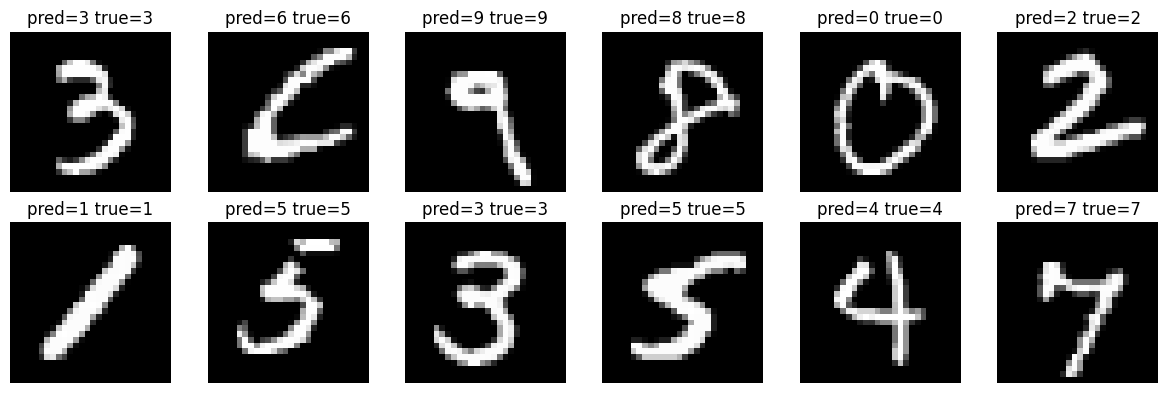

In [12]:
# To-Do: visualize a few predictions with matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Ensure we have the model and x_test, y_test from Exercise 3
N = 12  # number of test images to visualize

# Select N random indices from the test set
idx = np.random.choice(len(x_test), size=N, replace=False)

x_vis = x_test[idx]
y_true = y_test[idx]

# Get predictions (probabilities for each class)
y_prob = model.predict(x_vis)

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_prob, axis=1)

# Plotting
cols = 6
rows = int(np.ceil(len(idx) / cols))

plt.figure(figsize=(12, 2 * rows))
for i, k in enumerate(idx, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(x_test[k], cmap="gray")
    plt.title(f"pred={y_pred[i-1]} true={y_true[i-1]}")
    plt.axis("off")

plt.tight_layout()
plt.show()